# 02 — Wave Layer: Regime Classification & Permissions

**Strategy reference:** §8 (Wave), §18 (Permissions Matrix).

Wave classifies the *meso-scale* environment and publishes a
`PermissionSet` that decides which Ripple archetypes can fire.
It runs every ~5 s, on L1 data only (no L2).

Four regimes:

| label | meaning |
|---|---|
| `MEAN_REVERSION` | low η, low dispersion → choppy |
| `BREAKOUT`       | high η, direction up → trending |
| `BREAKDOWN`      | high η, direction down OR extreme stress |
| `NEUTRAL`        | nothing strong |

In [1]:
# ── Data-source configuration ─────────────────────────────────────────
# OHLCV (Parquet) — S3 or local, controlled by DATA_STORE env var:
#   Local (default):  reads <project_root>/data/ohlcv/...
#   S3:               uncomment the two lines below
# import os
# os.environ["DATA_STORE"] = "s3"
# os.environ["S3_BUCKET"]  = "trading-data-centheos"
#
# Tick data (HDF5) — always stored locally; pull from S3 on demand:
#   load_ticks(...)              → use local cache (fast, no network)
#   load_ticks(..., refresh=True) → sync from S3 then read (ETag-gated)
#   Requires: AWS_PROFILE=trading (or AWS_ACCESS_KEY_ID / AWS_SECRET_ACCESS_KEY)
import os
os.environ["AWS_PROFILE"] = "trading"
os.environ["S3_BUCKET"]   = "trading-data-centheos"
# ─────────────────────────────────────────────────────────────────────

import sys, importlib
from pathlib import Path

_here = Path.cwd().resolve()
for _cand in [_here, *_here.parents]:
    if (_cand / "schemas.py").exists():
        _root = _cand; break
else:
    raise RuntimeError("Could not locate project root (no schemas.py found)")
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import notebooks.utils as _utils_mod
importlib.reload(_utils_mod)   # always pick up on-disk changes without restarting the kernel

from notebooks.utils import (
    load_ohlcv, list_ohlcv, load_ticks, latest_book,
    plot_ohlcv, plot_equity_curve, configure_pandas, env_summary,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

configure_pandas()
%matplotlib inline

In [2]:
from schemas import (
    WaveConfig, WaveRegime, TideBias, PermissionLevel,
    TradeArchetype, TradeSide,
)
from wave.wave_engine import (
    WaveEngine, lookup_permissions,
    compute_trend_efficiency, compute_trend_direction,
)
from wave.wave_features import WaveFeatureParams, build_wave_feature_frame

## 1. Load OHLCV

In [3]:
ohlcv = load_ohlcv('binance', 'BTCUSDT', '1m').tail(20_000).copy()
print(f'{len(ohlcv):,} bars')

20,000 bars


## 2. Trend efficiency η (§8.5.4)
$$\eta = \frac{|\sum \Delta P_i|}{\sum |\Delta P_i|}$$

Demo on three synthetic windows so the intuition is clear.

In [4]:
rng = np.random.default_rng(0)
trend = np.cumsum(rng.normal(0.1, 1, 200))
chop  = np.cumsum(rng.normal(0.0, 1, 200))
mixed = np.concatenate([trend, chop[::-1]])
for name, series in [('trending', trend), ('chop', chop), ('mixed', mixed)]:
    print(f'{name:10s}  η = {compute_trend_efficiency(series.tolist()):.3f}'
          f'   dir = {compute_trend_direction(series.tolist()):+.1f}')

trending    η = 0.145   dir = +1.0
chop        η = 0.105   dir = -1.0
mixed       η = 0.002   dir = -1.0


## 3. Build the full Wave feature frame
`build_wave_feature_frame` gives us rolling η, dispersion proxy,
absorption-ratio proxy, VWAP, structural high/low, and
distance-to-VWAP.

In [5]:
wparams = WaveFeatureParams(
    eta_window=30, vwap_window=60, structure_window=120,
    disp_window=30, ar_window=120,
)
wf = build_wave_feature_frame(ohlcv, wparams)
wf.tail()

,close,log_return,eta,dispersion,ar,vwap,structure_high,structure_low,distance_vwap
timestamp,,,,,,,,,
2026-05-21 09:54:00,"77,622.000000",-0.000093,0.569929,0.006363,0.858080,"77,785.226664","78,111.000000","77,622.000000",-0.002103
2026-05-21 09:55:00,"77,639.000000",0.000219,0.514776,0.006466,0.871070,"77,779.601498","78,111.000000","77,622.000000",-0.001811
2026-05-21 09:56:00,"77,657.000000",0.000232,0.460235,0.006574,0.912866,"77,774.529203","78,111.000000","77,622.000000",-0.001513
2026-05-21 09:57:00,"77,646.300000",-0.000138,0.477562,0.006558,0.910254,"77,772.237766","78,111.000000","77,622.000000",-0.001622
2026-05-21 09:58:00,"77,646.300000",0.000000,0.477852,0.006558,0.910603,"77,768.784127","78,111.000000","77,622.000000",-0.001577


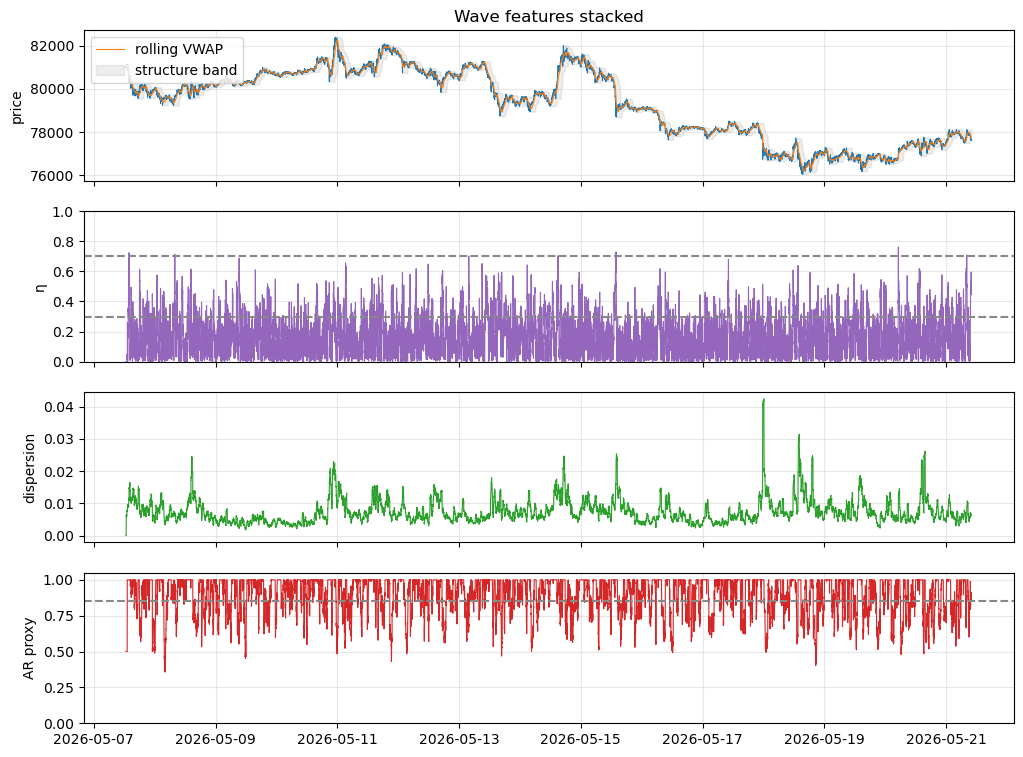

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(ohlcv.index, ohlcv['close'], color='#1f77b4', linewidth=0.7)
axes[0].plot(wf.index, wf['vwap'], color='#ff7f0e', linewidth=0.8, label='rolling VWAP')
axes[0].fill_between(wf.index, wf['structure_low'], wf['structure_high'],
                     color='#888', alpha=0.15, label='structure band')
axes[0].legend(loc='upper left'); axes[0].set_ylabel('price'); axes[0].grid(alpha=0.3)
axes[1].plot(wf.index, wf['eta'], color='#9467bd', linewidth=0.8)
axes[1].axhline(0.3, ls='--', color='#888'); axes[1].axhline(0.7, ls='--', color='#888')
axes[1].set_ylabel('η'); axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 1)
axes[2].plot(wf.index, wf['dispersion'], color='#2ca02c', linewidth=0.8)
axes[2].set_ylabel('dispersion'); axes[2].grid(alpha=0.3)
axes[3].plot(wf.index, wf['ar'], color='#d62728', linewidth=0.8)
axes[3].axhline(0.85, ls='--', color='#888'); axes[3].set_ylabel('AR proxy')
axes[3].grid(alpha=0.3); axes[3].set_ylim(0, 1.05)
axes[0].set_title('Wave features stacked')
plt.show()

## 4. Permissions matrix (§18)
12 cells of `(TideBias × WaveRegime)` map to a `PermissionSet`
with one entry per (archetype × side).  We extract the table from
the live engine and visualise it as a heatmap.

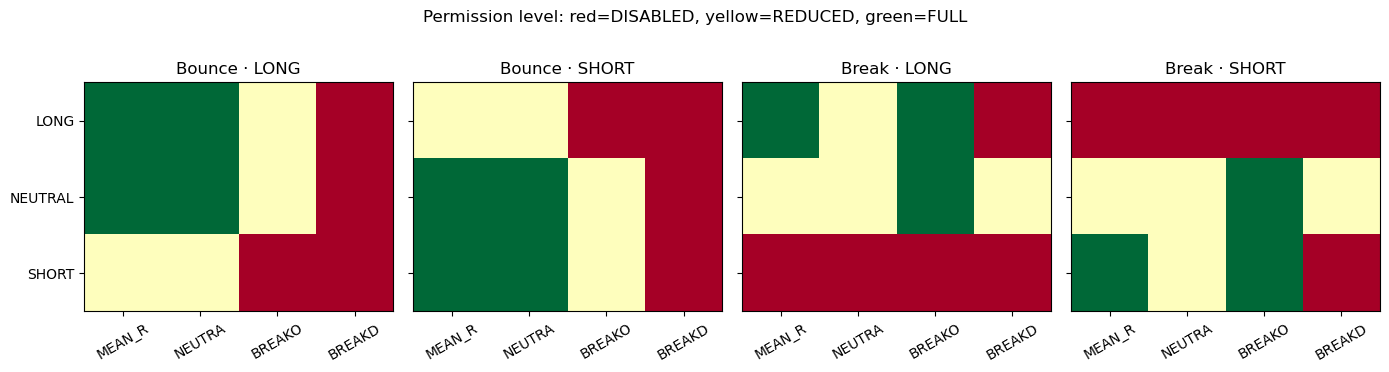

In [7]:
level_to_int = {PermissionLevel.DISABLED: 0, PermissionLevel.REDUCED: 1, PermissionLevel.FULL: 2}
biases  = [TideBias.LONG, TideBias.NEUTRAL, TideBias.SHORT]
regimes = [WaveRegime.MEAN_REVERSION, WaveRegime.NEUTRAL, WaveRegime.BREAKOUT, WaveRegime.BREAKDOWN]
arch_sides = [('Bounce', TradeArchetype.BOUNCE, TradeSide.LONG),
              ('Bounce', TradeArchetype.BOUNCE, TradeSide.SHORT),
              ('Break',  TradeArchetype.BREAKOUT, TradeSide.LONG),
              ('Break',  TradeArchetype.BREAKOUT, TradeSide.SHORT)]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6), sharey=True)
for ax, (label, arch, side) in zip(axes, arch_sides):
    M = np.zeros((len(biases), len(regimes)))
    for i, b in enumerate(biases):
        for j, r in enumerate(regimes):
            perm = lookup_permissions(b, r)
            M[i, j] = level_to_int[perm.get(arch, side)]
    im = ax.imshow(M, cmap='RdYlGn', vmin=0, vmax=2, aspect='auto')
    ax.set_xticks(range(len(regimes)))
    ax.set_xticklabels([r.value[:6] for r in regimes], rotation=30)
    ax.set_yticks(range(len(biases))); ax.set_yticklabels([b.value for b in biases])
    ax.set_title(f'{label} · {side.value}')
fig.suptitle('Permission level: red=DISABLED, yellow=REDUCED, green=FULL', y=1.02)
plt.tight_layout(); plt.show()

## 5. Drive the WaveEngine
Feed prices into `WaveEngine` at Wave cadence and capture the
regime label per update.  Pin TideBias to `LONG` so we get the
non-trivial branch of the permission table.

In [8]:
engine = WaveEngine(WaveConfig(update_interval_ms=60_000))
engine.set_price_window_ms(60 * 60 * 1000)  # 60-min η window

regime_to_int = {WaveRegime.NEUTRAL: 0, WaveRegime.MEAN_REVERSION: 1,
                 WaveRegime.BREAKOUT: 2, WaveRegime.BREAKDOWN: 3}

labels = []
etas = []
for ts, close in ohlcv['close'].items():
    ts_ms = int(ts.value // 1_000_000)
    engine.on_price(float(close), ts_ms)
    snap = engine.update(ts_ms, bias=TideBias.LONG)
    if snap is not None:
        labels.append((ts, regime_to_int[snap.regime], snap.trend_efficiency))
labels_df = pd.DataFrame(labels, columns=['ts', 'regime_int', 'eta']).set_index('ts')
labels_df.tail()

,regime_int,eta
ts,,
2026-05-21 09:54:00,1,0.250325
2026-05-21 09:55:00,1,0.256867
2026-05-21 09:56:00,1,0.269899
2026-05-21 09:57:00,1,0.261719
2026-05-21 09:58:00,1,0.259206


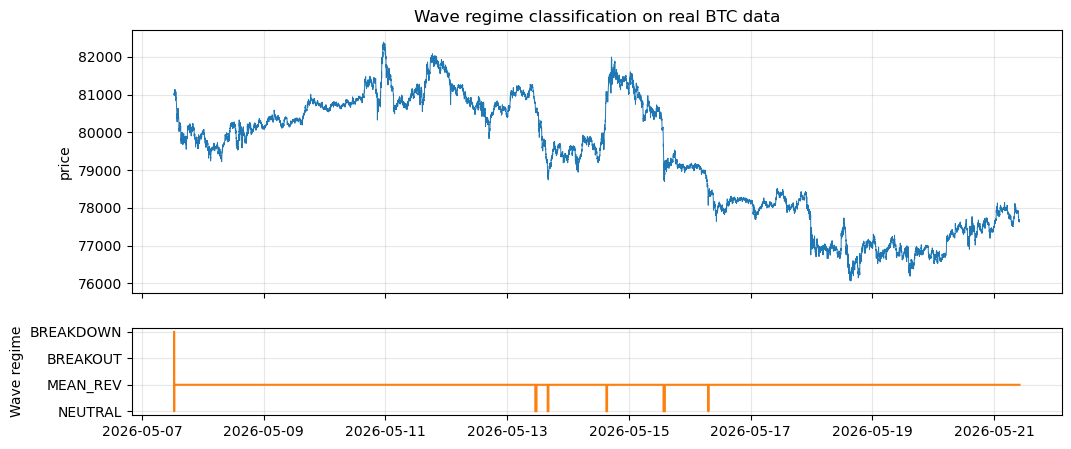

regime_int
MEAN_REV     19902
NEUTRAL         97
BREAKDOWN        1
Name: count, dtype: int64

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(ohlcv.index, ohlcv['close'], color='#1f77b4', linewidth=0.7)
axes[0].set_ylabel('price'); axes[0].grid(alpha=0.3)
axes[1].step(labels_df.index, labels_df['regime_int'], where='post', color='#ff7f0e')
axes[1].set_yticks([0, 1, 2, 3])
axes[1].set_yticklabels(['NEUTRAL', 'MEAN_REV', 'BREAKOUT', 'BREAKDOWN'])
axes[1].grid(alpha=0.3); axes[1].set_ylabel('Wave regime')
axes[0].set_title('Wave regime classification on real BTC data')
plt.show()
labels_df['regime_int'].value_counts().rename({0:'NEUTRAL',1:'MEAN_REV',2:'BREAKOUT',3:'BREAKDOWN'})

## 6. Regime → permission overlay
For every Wave update, what `PermissionSet` would Ripple have
received?  We compute the fraction of time each archetype was
fully enabled vs reduced vs blocked.

In [10]:
engine.reset()
engine.set_price_window_ms(60 * 60 * 1000)
rows = []
for ts, close in ohlcv['close'].items():
    ts_ms = int(ts.value // 1_000_000)
    engine.on_price(float(close), ts_ms)
    snap = engine.update(ts_ms, bias=TideBias.LONG)
    if snap is None:
        continue
    p = snap.permissions
    rows.append({
        'ts': ts,
        'long_bounce':    p.long_bounce.value,
        'short_bounce':   p.short_bounce.value,
        'long_breakout':  p.long_breakout.value,
        'short_breakout': p.short_breakout.value,
    })
permissions_df = pd.DataFrame(rows).set_index('ts')
for col in permissions_df.columns:
    print(col, '\n', permissions_df[col].value_counts(normalize=True).round(3).to_dict())

long_bounce 
 {'FULL': 1.0, 'DISABLED': 0.0}
short_bounce 
 {'REDUCED': 1.0, 'DISABLED': 0.0}
long_breakout 
 {'FULL': 0.995, 'REDUCED': 0.005, 'DISABLED': 0.0}
short_breakout 
 {'DISABLED': 1.0}


## Takeaways

* Wave's job is binary classification + permission lookup — no PnL
  decisions, no sizing, no trades.
* The dispersion / AR proxies are V1 single-symbol stand-ins; the
  multi-asset versions (§8.5.2 / §8.5.3) come online when more
  symbols are streamed alongside.
* The permissions heatmap is the single artefact Ripple cares
  about — every other Wave output is for observability.